# 02 · Análisis exploratorio (EDA) del corpus TASS 2020 por variedad

Este notebook explora los datos reales que están en `data/train` y `data/dev` (un TSV por país, sin encabezado: `id`, texto, etiqueta).
Usa las mismas funciones que `scripts/eda/run_eda.py`, así que las cifras coinciden con las tablas de `docs/eda/tablas/`.

**Preguntas que intenta responder**

1. ¿Qué tan grandes, limpios y balanceados están los datos en cada variedad?
2. ¿Hay diferencias entre países que puedan confundirse con "dialecto"?
3. ¿Hay suficientes ejemplos de los fenómenos lingüísticos que motivan al agente de Percepción?
4. ¿Qué piso de desempeño hay que superar, y con qué margen de error se mide en cada país?

Aquí no se entrena ni se evalúa ningún modelo. Los textos mostrados se anonimizan (`@USUARIO`).

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

RAIZ = Path("..").resolve()
sys.path.insert(0, str(RAIZ / "scripts" / "eda"))
import eda_utils as E
import run_eda as R

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
FIG = RAIZ / "docs" / "eda" / "figuras"

def mostrar(fn, *args, nombre):
    ruta = FIG / nombre
    fn(*args, ruta)
    display(Image(filename=str(ruta)))

## 1. Carga y tamaño

In [2]:
corpus = E.cargar_corpus(RAIZ / "data")
df = E.agregar_fecha(E.agregar_fenomenos(E.agregar_rasgos(corpus)))
print(f"{len(df):,} tuits · variedades: {sorted(df.variedad.unique())}")
E.resumen_por_variedad(df)

7,267 tuits · variedades: ['CR', 'ES', 'MX', 'PE', 'UY']


split,variedad,dev,train,total,longitud_media_car,longitud_media_pal
0,CR,390,777,1167,85.3,15.6
1,ES,581,1126,1707,91.5,15.9
2,MX,510,990,1500,91.9,17.0
3,PE,498,966,1464,90.7,16.3
4,UY,486,943,1429,88.8,15.8


  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig01_tamano.png


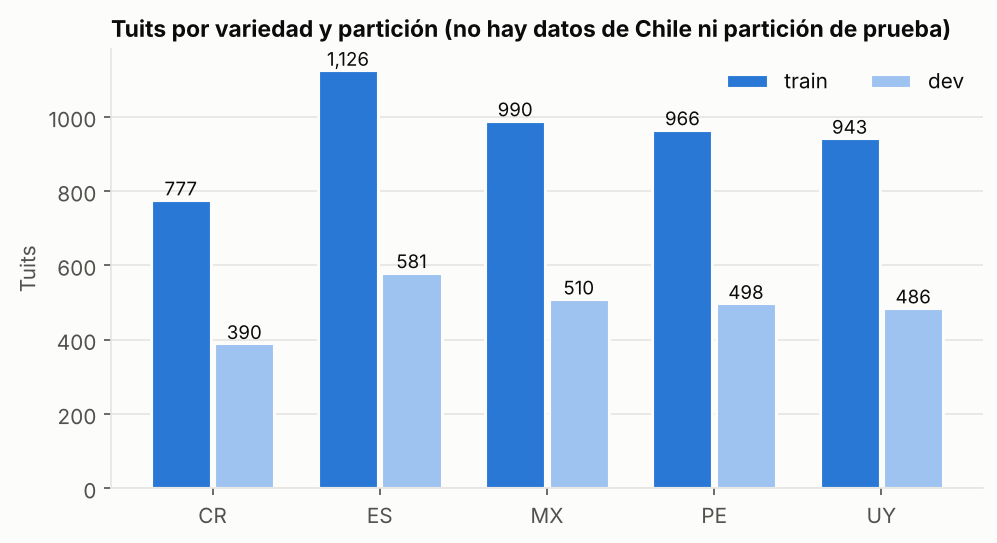

In [3]:
mostrar(R.fig_tamano, corpus, nombre="fig01_tamano.png")

**Lectura.** Son cinco variedades (CR, ES, MX, PE, UY): Entre 1.167 y 1.707 tuits por país, repartidos en *train* (~2/3) y *dev* (~1/3). **No hay partición de prueba**: habrá que decidir de dónde sale el conjunto bloqueado.

## 2. Calidad de los datos

In [4]:
E.reporte_calidad(corpus)

,chequeo,casos
0,Filas totales,7267
1,Textos vacíos,0
2,Ids repetidos (filas extra),2
3,Textos repetidos tras normalizar (filas extra),16
4,Textos repetidos con etiquetas distintas (textos),2
5,Ids presentes en train y dev a la vez,1
6,Textos presentes en train y dev a la vez,3
7,Tuits con URL,45


**Lectura.** Los datos están bastante limpios: ningún texto vacío y muy pocos repetidos. Lo único que merece atención son **2 textos que aparecen con etiquetas distintas** (por ejemplo el mismo tuit marcado P en *train* y NEU en *dev*) y **3 textos presentes en ambas particiones**. Son casos mínimos, pero conviene depurarlos antes de evaluar.

## 3. Distribución de etiquetas

  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig02_etiquetas.png


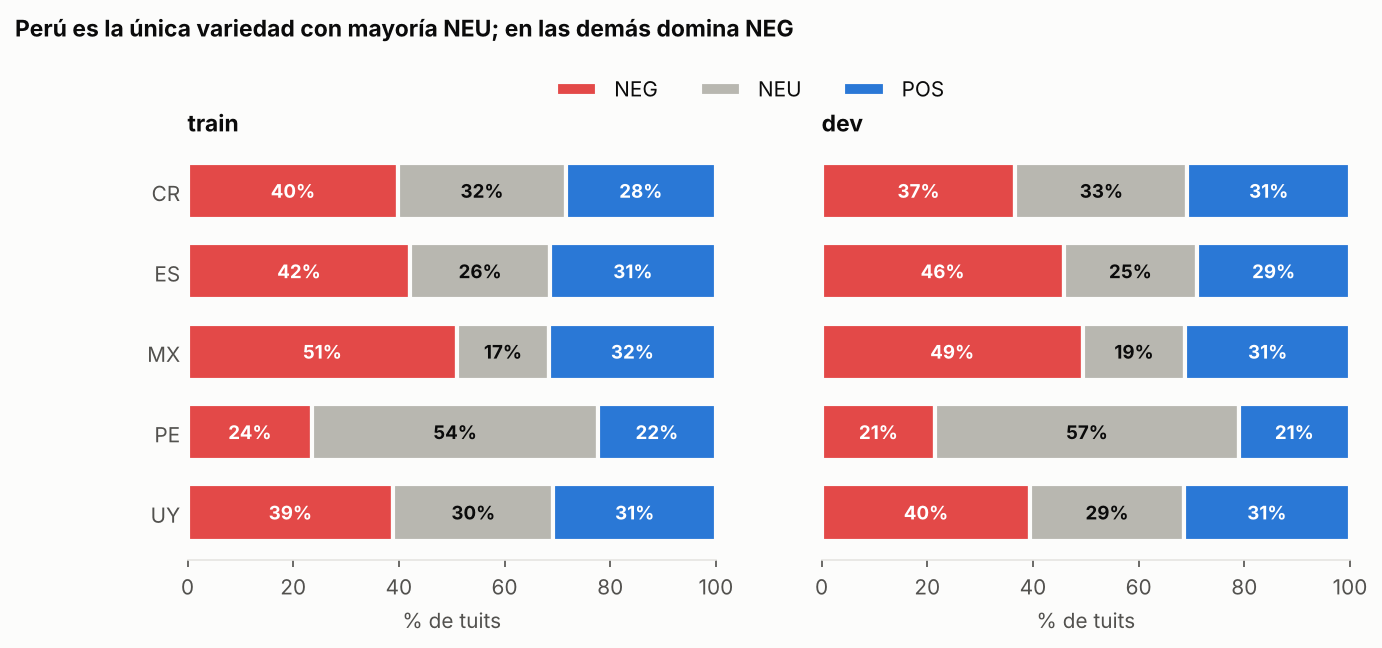

In [5]:
mostrar(R.fig_etiquetas, corpus, nombre="fig02_etiquetas.png")

In [6]:
E.asociacion_etiqueta_variedad(corpus).round(4)

,comparacion,variedad,chi2,p_valor,v_cramer
0,Etiqueta vs. variedad (train),todas,344.7594,0.0000,0.1895
1,Etiqueta vs. split (train/dev),CR,1.2454,0.5365,0.0327
2,Etiqueta vs. split (train/dev),ES,2.1114,0.3480,0.0352
3,Etiqueta vs. split (train/dev),MX,0.9649,0.6173,0.0254
4,Etiqueta vs. split (train/dev),PE,1.5725,0.4556,0.0328
5,Etiqueta vs. split (train/dev),UY,0.2692,0.8741,0.0137


**Lectura.** Perú es la única variedad donde NEU es mayoría (54% en *train*, 57% en *dev*); en las demás domina NEG (hasta 51% en MX). La asociación etiqueta–variedad es real aunque moderada (V de Cramér ≈ 0,19). Dentro de cada país, *train* y *dev* tienen distribuciones parecidas (p entre 0,35 y 0,87), así que no hay un cambio brusco entre particiones.

Una explicación posible es que el criterio de anotación de NEU/NONE difiera entre los subcorpus. Es una hipótesis, no un hallazgo: hay que contrastarla con el *overview* de TASS 2020 antes de interpretar las diferencias entre países como diferencias de dialecto.

## 4. Rasgos del texto

  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig03_longitud.png


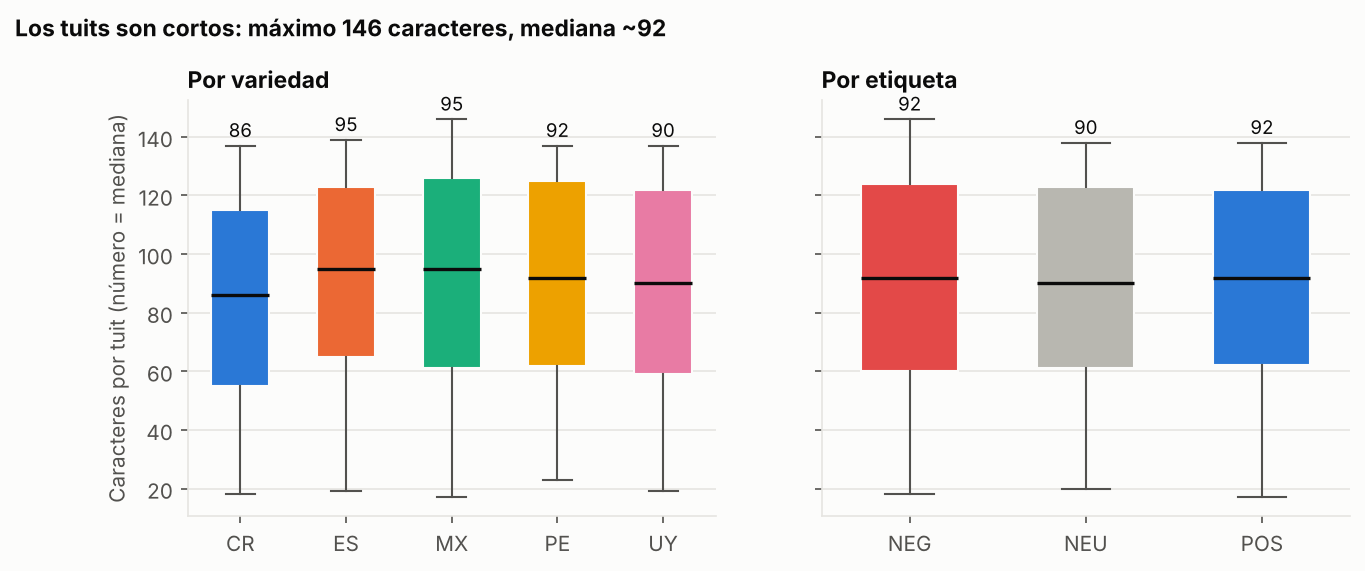

In [7]:
mostrar(R.fig_longitud, df, nombre="fig03_longitud.png")

  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig04_rasgos.png


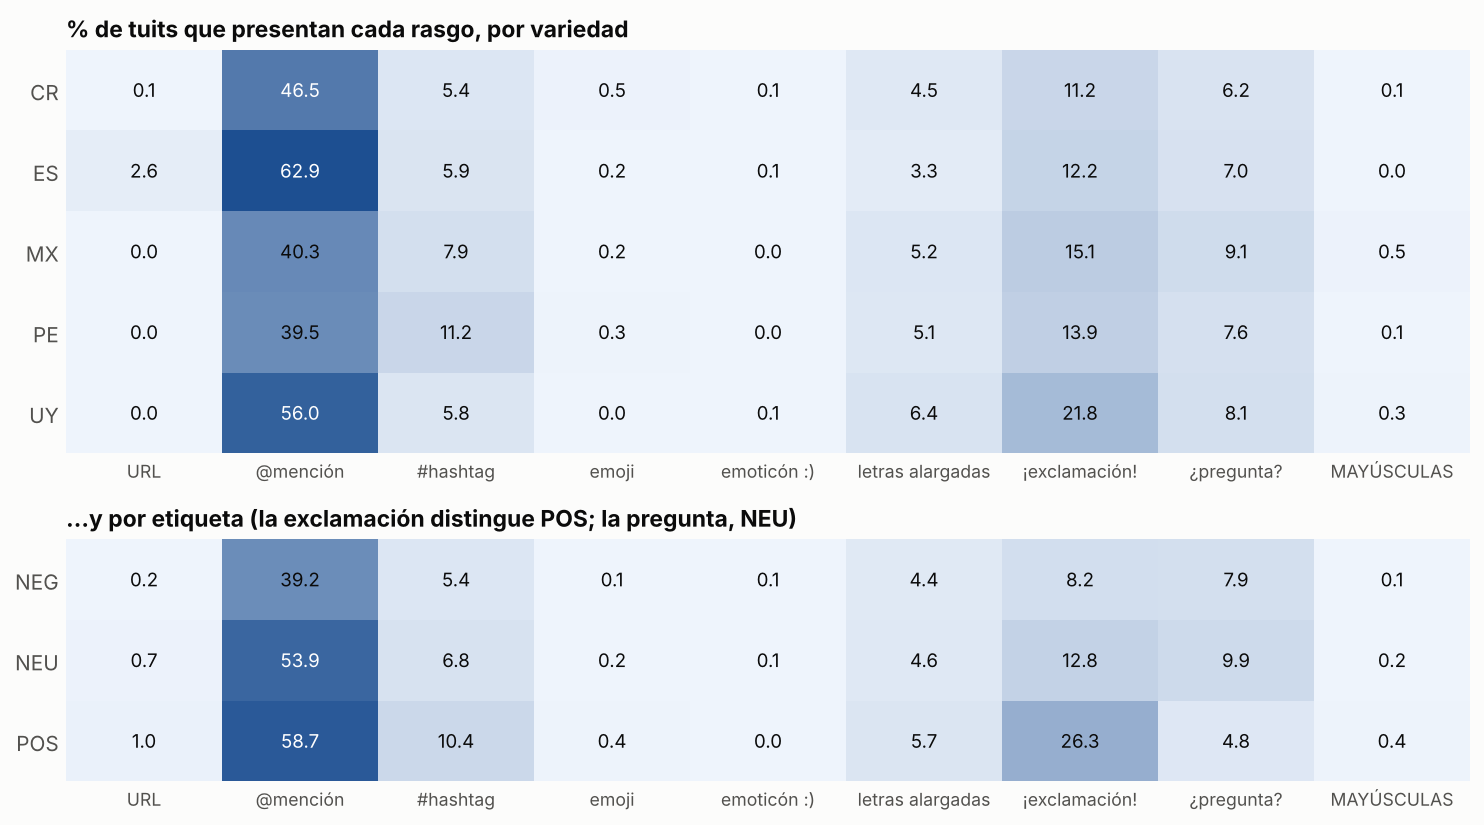

In [8]:
mostrar(R.fig_rasgos, df, nombre="fig04_rasgos.png")

**Lectura.**
- Los tuits son **cortos**: mediana de ~92 caracteres y máximo de 146 (unas 16 palabras). Cada llamada al LLM procesará muy poco texto del usuario, así que el costo lo marcarán las instrucciones del prompt y el número de muestras, no el tuit.
- **Casi no hay emojis** (entre 0 y 0,5% de los tuits) ni emoticonos. La perturbación "emojis equivalentes" prevista para la prueba de robustez no tiene dónde aplicarse.
- La exclamación es una pista fuerte de polaridad positiva (26% de los POS frente a 8% de los NEG); la pregunta aparece más en NEU (10%). Un monoagente simple podría apoyarse en esas señales superficiales.
- Entre 40% y 63% de los tuits lleva una @mención (ES la más alta): los textos son conversacionales.

## 5. Fenómenos lingüísticos (estimación con heurísticas)

  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig05_fenomenos.png


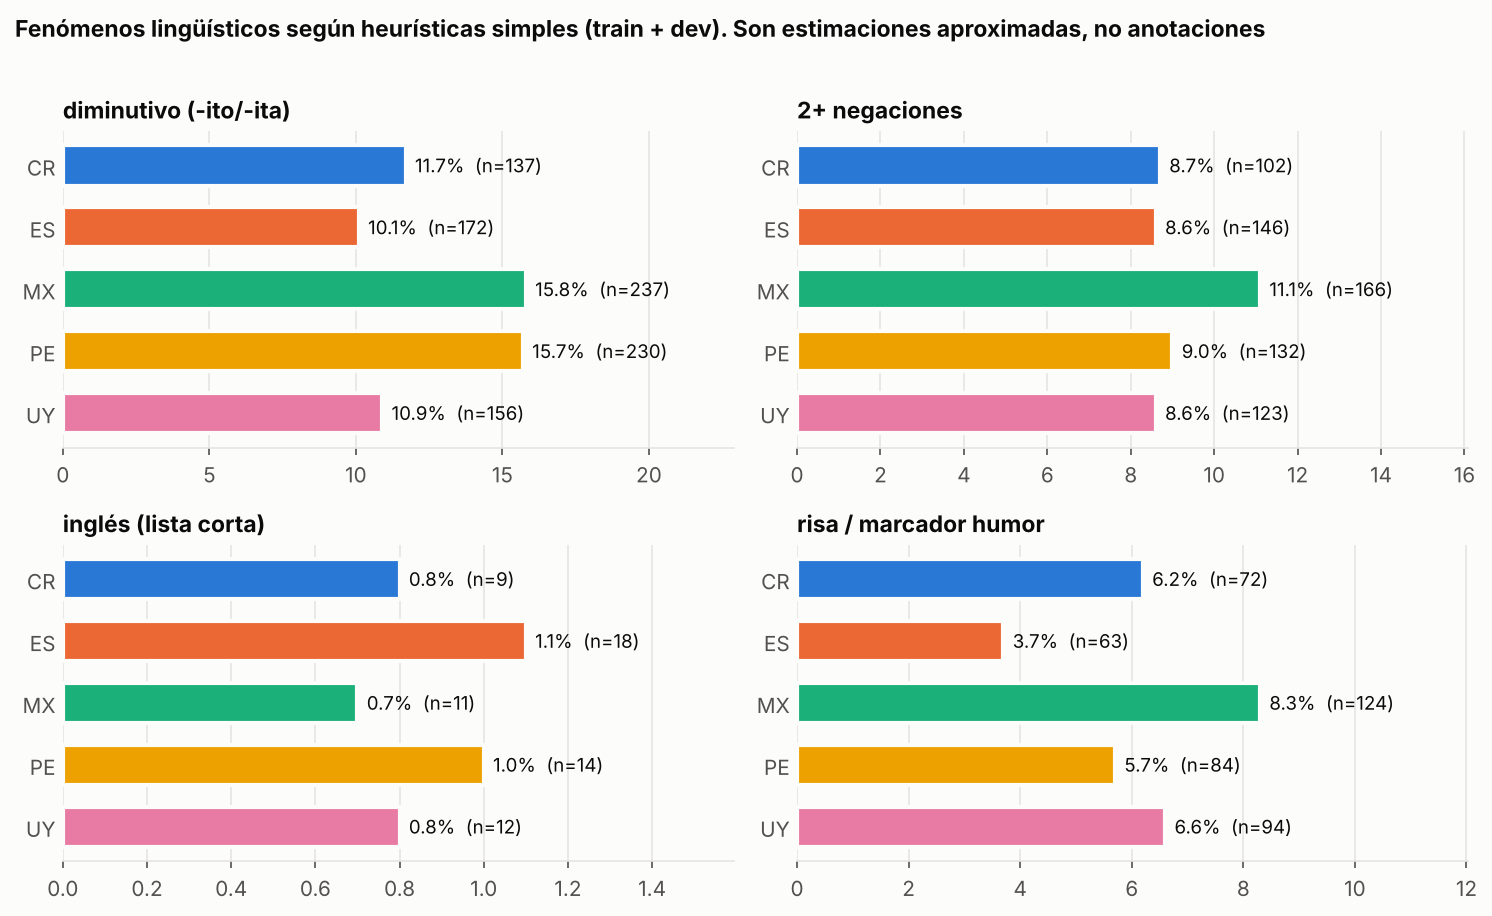

In [9]:
mostrar(R.fig_fenomenos, df, nombre="fig05_fenomenos.png")

In [10]:
print("Solo en dev (lo que se usaría para diseñar prompts):")
E.tabla_fenomenos(df, "dev")[["diminutivo_afectivo","doble_negacion","code_switching","sarcasmo_aparente","n"]]

Solo en dev (lo que se usaría para diseñar prompts):


,diminutivo_afectivo,doble_negacion,code_switching,sarcasmo_aparente,n
variedad,,,,,
CR,46,42,4,26,390
ES,67,50,6,22,581
MX,79,54,3,42,510
PE,77,52,2,23,498
UY,53,47,7,35,486


**Lectura.** Estas cifras salen de reglas simples y **no son anotaciones**. En una revisión rápida de unos 10 casos por regla:
- *Diminutivos* (10–16%): la mayoría son reales (`gatitos`, `besitos`), pero la regla también marca palabras como `éxitos`.
- *2+ negaciones* (9–11%): cuenta cualquier tuit con dos negaciones, no solo la doble negación enfática.
- *Inglés* (0,7–1,1%): sirve como indicio, pero es una lista corta de palabras.
- *Risa* (4–8%): la regla que el script de auditoría llama "sarcasmo aparente" detecta en realidad `jaja`/`jeje`. **No mide sarcasmo.** Aquí se muestra como "risa / marcador humor".

El dato clave es el **code-switching**: 64 tuits en total y entre 2 y 7 por país en *dev*. No alcanza para sacar conclusiones por país sobre ese fenómeno. Para el resto hará falta una anotación manual; `docs/eda/tablas/muestra_validar_heuristicas.csv` trae una muestra anonimizada con una columna para confirmar a mano cada marca.

## 6. Tiempo y vocabulario

  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig06_temporal.png


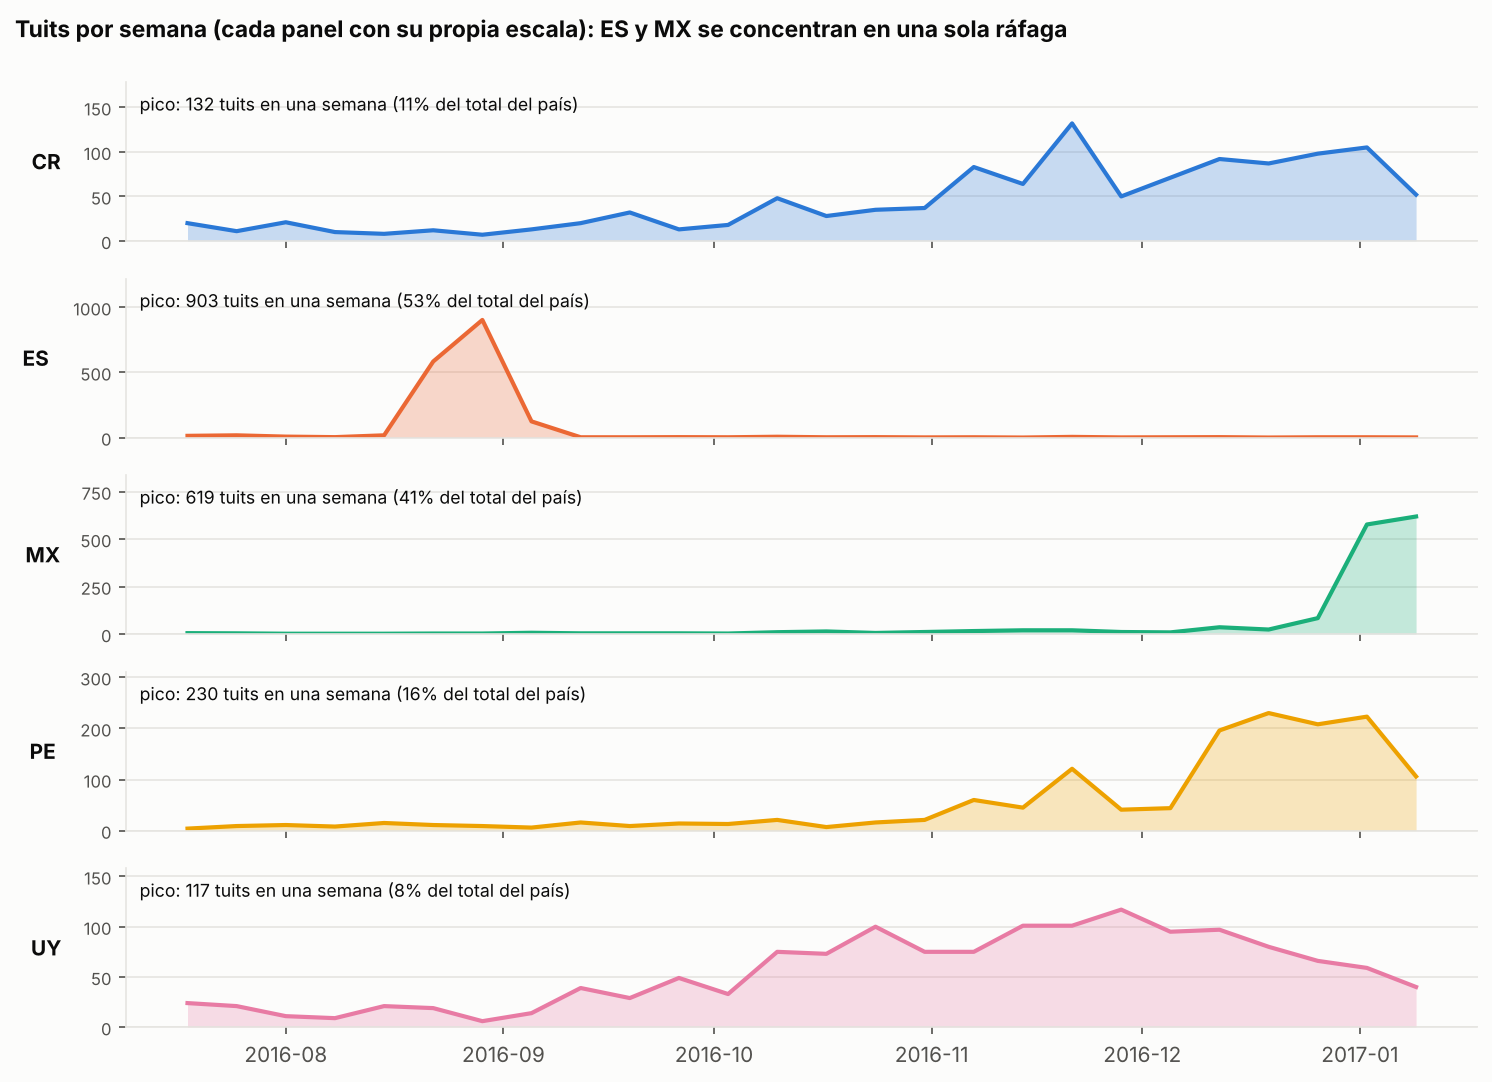

In [11]:
mostrar(R.fig_temporal, df, nombre="fig06_temporal.png")

In [12]:
E.concentracion_temporal(df)

,variedad,semanas_con_tuits,semana_pico,tuits_semana_pico,pct_en_semana_pico,pct_en_2_semanas_top,mediana_fecha_train,mediana_fecha_dev,dias_dev_despues_de_train,ks_D_train_vs_dev
0,CR,26,2016-11-21,132,11.3,20.3,2016-11-16,2016-12-29,42,0.604
1,ES,24,2016-08-29,903,52.9,87.1,2016-08-29,2016-08-30,0,0.171
2,MX,26,2017-01-09,619,41.3,79.7,2017-01-05,2017-01-11,5,0.585
3,PE,26,2016-12-19,230,15.7,30.9,2016-12-14,2017-01-03,19,0.603
4,UY,26,2016-11-28,117,8.2,15.3,2016-10-31,2016-12-18,47,0.597


In [13]:
E.vocabulario_distintivo(df).pivot(index="rank", columns="variedad", values="termino")

variedad,CR,ES,MX,PE,UY
rank,,,,,
1,dicha,septiembre,neta,chamba,uruguay
2,mae,tio,chido,perú,tremenda
3,costa,valencia,rosca,lima,envianos
4,rica,podido,pax,felices,argentina
5,fijo,madrid,pinche,éxitos,sos
6,mami,españa,verga,junto,descanses
7,bus,verano,tacos,debo,lastima
8,ahorita,echo,pedo,felicidad,tqm
9,videos,calor,mensajes,quisiera,mail


**Lectura.** La fecha se obtiene del id del tuit. Todos son de **julio de 2016 a enero de 2017**, pero la distribución es muy irregular:
- En **ES el 87%** de los tuits cae en dos semanas (finales de agosto de 2016) y en **MX el 80%** en dos semanas (enero de 2017).
- En CR, PE y UY, el *dev* es sistemáticamente **posterior** al *train* (6 a 7 semanas de diferencia en la mediana de CR y UY; D de Kolmogorov–Smirnov ≈ 0,6).
- El vocabulario distintivo mezcla dialecto real (`chamba`, `neta`, `chido`, `mae`, `vos`) con **lugares y temas de actualidad** (`valencia`, `madrid`, `lima`, `uruguay`, `reyes`).

Por tanto, las diferencias de desempeño entre países se confunden con diferencias de época y de tema. Hay que presentarlas con cautela y no atribuirlas sin más al dialecto. Dentro de las ráfagas de ES y MX, la distribución de etiquetas es casi igual a la del resto (ES: 43% NEG dentro del pico vs. 44% fuera), así que no parece que las ráfagas sesguen la polaridad.

## 7. Piso de desempeño y margen de error

  figura: /tmp/claude-0/-home-claude/0732e640-faf6-53b6-88dc-02e454ae2215/scratchpad/work/multiagente-analisis-sentimiento-es/docs/eda/figuras/fig07_baseline_mayoritario.png


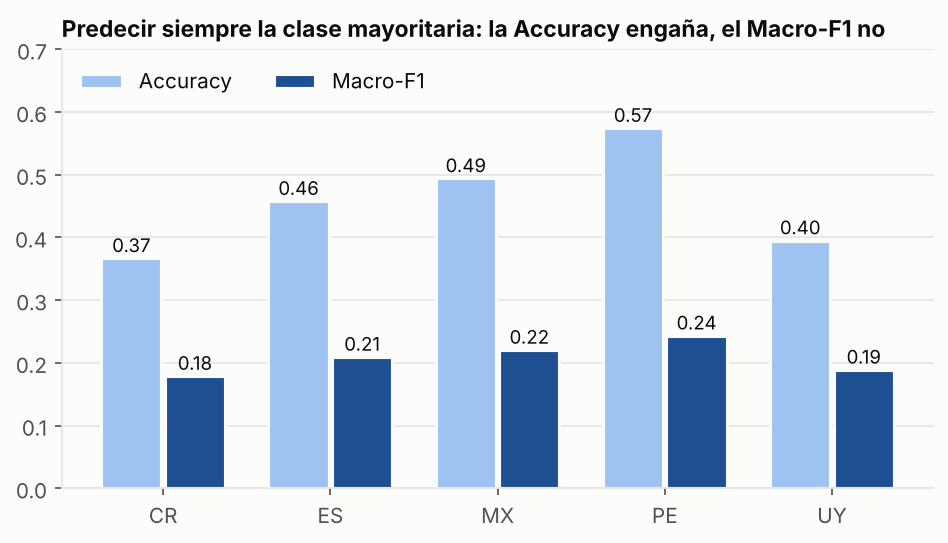

In [14]:
mostrar(R.fig_baseline, E.baseline_mayoritario(corpus), nombre="fig07_baseline_mayoritario.png")

In [15]:
E.baseline_mayoritario(corpus).round(3)

,variedad,clase_mayoritaria_train,n_dev,accuracy_dev,macro_f1_dev,margen_error_max_pp
0,CR,NEG,390,0.367,0.179,4.962
1,ES,NEG,581,0.458,0.209,4.066
2,MX,NEG,510,0.494,0.220,4.340
3,PE,NEU,498,0.574,0.243,4.391
4,UY,NEG,486,0.395,0.189,4.445


**Lectura.** Predecir siempre la clase mayoritaria da un Macro-F1 de 0,18 a 0,24 en *dev*, aunque la Accuracy llegue a 0,57 en PE. Ese es el piso que cualquier sistema debe superar y muestra por qué el **Macro-F1 es la métrica principal**: la Accuracy premia al que acierta la clase dominante.

Con ~400–580 tuits de *dev* por país, el margen de error máximo de una Accuracy es de ±4 a ±5 puntos porcentuales. Una mejora de 0,02 en Macro-F1 queda dentro de ese margen para cada país por separado, de modo que las pruebas pareadas y el análisis conjunto serán imprescindibles, y por país probablemente solo se detecten diferencias mayores.

## 8. Qué cambia en el proyecto

1. **Conjunto de prueba**: no existe. Decidir si el *dev* oficial se usa como prueba bloqueada (conserva el orden temporal) o si se reparte todo de nuevo.
2. **Robustez**: quitar los emojis del catálogo de perturbaciones y usar tildes, tipeo, mayúsculas, letras alargadas y abreviaturas.
3. **Fenómenos**: renombrar "sarcasmo aparente" en `audit_phenomena.py` y planificar anotación manual (code-switching no alcanza para análisis por país).
4. **Interpretación por país**: reportar junto a cada resultado la concentración temporal y el posible efecto de anotación de NEU en Perú.
5. **Configuración**: con tuits de ≤146 caracteres, `contexto_maximo_tokens: 8192` está muy sobredimensionado.